# FinSight AI — Real Market Analytics
**Stack:** Python · yfinance · Pandas · NumPy · Plotly · Anthropic API  
**Dataset:** Real historical OHLCV data pulled live from Yahoo Finance (2022–2024)
**Tickers:** AAPL · MSFT · GOOGL · NVDA · META

---
Run each cell with **Shift + Enter**, or **Kernel → Restart & Run All**

> Data is pulled live each time you run — charts reflect actual market history including the 2022 rate hike selloff, AI boom of 2023, and NVDA's surge.

## 1. Setup & Imports

In [1]:
# Install yfinance if not already installed
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'yfinance', '-q'], capture_output=True)

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__} | yfinance: {yf.__version__}')
print('All libraries loaded.')


NumPy: 2.2.4 | Pandas: 2.2.3 | yfinance: 1.2.0
All libraries loaded.


## 2. Pull Real Market Data from Yahoo Finance
Using `yfinance` to pull 2 years of real daily OHLCV data.  
This is actual market data — every price reflects what really happened.

In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META']
START = '2022-01-01'
END   = '2024-12-31'

print(f'Pulling real market data from Yahoo Finance...')
print(f'Tickers: {TICKERS}')
print(f'Period: {START} to {END}')

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)

# Extract close and volume
close = raw['Close'].dropna()
volume = raw['Volume'].dropna()
high = raw['High'].dropna()
low = raw['Low'].dropna()
open_ = raw['Open'].dropna()

# Align all to same dates
dates = close.index

print(f'\nData pulled successfully!')
print(f'Trading days: {len(dates):,}')
print(f'Date range: {dates[0].date()} to {dates[-1].date()}')
print(f'Total data points: {len(dates) * len(TICKERS):,}')
print(f'\nLatest closing prices:')
for t in TICKERS:
    print(f'  {t}: ${close[t].iloc[-1]:.2f}')


Pulling real market data from Yahoo Finance...
Tickers: ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META']
Period: 2022-01-01 to 2024-12-31

Data pulled successfully!
Trading days: 752
Date range: 2022-01-03 to 2024-12-30
Total data points: 3,760

Latest closing prices:
  AAPL: $250.83
  MSFT: $420.76
  GOOGL: $190.36
  NVDA: $137.44
  META: $588.88


## 3. Returns & Statistical Analysis

In [3]:
# Daily log returns
returns = np.log(close / close.shift(1)).dropna()

ANN = 252  # trading days per year

stats_rows = []
for ticker in TICKERS:
    r = returns[ticker].dropna()
    p = close[ticker].dropna()

    ann_ret  = r.mean() * ANN * 100
    ann_vol  = r.std()  * np.sqrt(ANN) * 100
    sharpe   = ann_ret / ann_vol
    var95    = np.percentile(r, 5) * 100
    var99    = np.percentile(r, 1) * 100
    cum      = (1 + r).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min() * 100
    total_ret = (p.iloc[-1] / p.iloc[0] - 1) * 100

    stats_rows.append({
        'Ticker':       ticker,
        'Start Price':  f'${p.iloc[0]:.2f}',
        'End Price':    f'${p.iloc[-1]:.2f}',
        'Total Return': f'{total_ret:+.1f}%',
        'Ann. Return':  f'{ann_ret:.2f}%',
        'Ann. Vol':     f'{ann_vol:.2f}%',
        'Sharpe':       f'{sharpe:.3f}',
        'VaR 95%':      f'{var95:.3f}%',
        'Max Drawdown': f'{max_dd:.2f}%',
        'Skewness':     f'{r.skew():.3f}',
        'Kurtosis':     f'{r.kurtosis():.3f}',
    })

stats_df = pd.DataFrame(stats_rows).set_index('Ticker')
print('=== Real Market Statistical Summary (2022-2024) ===')
print(stats_df.to_string())


=== Real Market Statistical Summary (2022-2024) ===
       Start Price End Price Total Return Ann. Return Ann. Vol Sharpe  VaR 95% Max Drawdown Skewness Kurtosis
Ticker                                                                                                       
AAPL       $178.10   $250.83       +40.8%      11.49%   27.06%  0.425  -2.757%      -34.34%    0.100    2.315
MSFT       $323.16   $420.76       +30.2%       8.86%   27.59%  0.321  -2.787%      -37.82%   -0.094    1.907
GOOGL      $143.80   $190.36       +32.4%       9.41%   32.77%  0.287  -3.215%      -46.83%   -0.134    2.774
NVDA        $30.06   $137.44      +357.2%      51.00%   54.67%  0.933  -5.412%      -67.38%    0.424    2.865
META       $335.90   $588.88       +75.3%      18.84%   49.48%  0.381  -4.209%      -78.95%   -1.471   26.139


## 4. Candlestick Charts — Real Price History

In [4]:
def plot_candlestick(ticker):
    o = open_[ticker]
    h = high[ticker]
    l = low[ticker]
    c = close[ticker]
    v = volume[ticker]
    ma20 = c.rolling(20).mean()
    ma50 = c.rolling(50).mean()

    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        row_heights=[0.75, 0.25], vertical_spacing=0.02)

    fig.add_trace(go.Candlestick(
        x=c.index, open=o, high=h, low=l, close=c,
        name=ticker,
        increasing_line_color='#1D9E75',
        decreasing_line_color='#D85A30'
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=ma20.index, y=ma20,
        line=dict(color='#378ADD', width=1.5), name='MA20'
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=ma50.index, y=ma50,
        line=dict(color='#EF9F27', width=1.5, dash='dot'), name='MA50'
    ), row=1, col=1)

    bar_colors = ['#1D9E75' if cv >= ov else '#D85A30'
                  for cv, ov in zip(c, o)]
    fig.add_trace(go.Bar(
        x=v.index, y=v,
        marker_color=bar_colors, opacity=0.6, name='Volume'
    ), row=2, col=1)

    total_ret = (c.iloc[-1] / c.iloc[0] - 1) * 100
    fig.update_layout(
        title=f'{ticker} — Real Price History (2022–2024) | '
              f'{len(c):,} trading days | Total return: {total_ret:+.1f}%',
        height=520,
        template='plotly_white',
        xaxis_rangeslider_visible=False,
        legend=dict(orientation='h', y=1.05)
    )
    fig.update_yaxes(title_text='Price ($)', row=1, col=1)
    fig.update_yaxes(title_text='Volume', row=2, col=1)
    fig.show()

for ticker in TICKERS:
    plot_candlestick(ticker)


## 5. Return Distributions & VaR
Real return distributions often show negative skew and fat tails — unlike the symmetric GBM model.

In [5]:
colors = ['#1D9E75', '#378ADD', '#7F77DD', '#EF9F27', '#D85A30']
positions = [(1,1),(1,2),(1,3),(2,1),(2,2)]

fig = make_subplots(rows=2, cols=3,
    subplot_titles=[f'{t} — Daily Returns' for t in TICKERS] + ['All Tickers Combined'],
    vertical_spacing=0.15, horizontal_spacing=0.08)

all_returns_list = []
for i, (ticker, color) in enumerate(zip(TICKERS, colors)):
    r = returns[ticker].dropna() * 100
    all_returns_list.append(r)
    row, col = positions[i]

    fig.add_trace(go.Histogram(
        x=r, nbinsx=60, name=ticker,
        marker_color=color, opacity=0.75,
        histnorm='probability density'
    ), row=row, col=col)

    var95 = np.percentile(r, 5)
    fig.add_vline(x=var95, line_dash='dash', line_color='red',
        annotation_text=f'VaR95: {var95:.2f}%',
        annotation_font_size=9, row=row, col=col)

all_r = pd.concat(all_returns_list)
fig.add_trace(go.Histogram(
    x=all_r, nbinsx=80,
    marker_color='#185FA5', opacity=0.7,
    histnorm='probability density', name='All'
), row=2, col=3)

total_pts = len(returns) * len(TICKERS)
fig.update_layout(
    title=f'Real Return Distributions — {total_pts:,} daily data points (Yahoo Finance)',
    height=580, template='plotly_white', showlegend=False
)
fig.show()

print('Skewness & Kurtosis (real markets show fat tails):')
for ticker in TICKERS:
    r = returns[ticker].dropna()
    print(f'  {ticker}: Skew={r.skew():.3f} | Kurt={r.kurtosis():.3f}')


Skewness & Kurtosis (real markets show fat tails):
  AAPL: Skew=0.100 | Kurt=2.315
  MSFT: Skew=-0.094 | Kurt=1.907
  GOOGL: Skew=-0.134 | Kurt=2.774
  NVDA: Skew=0.424 | Kurt=2.865
  META: Skew=-1.471 | Kurt=26.139


## 6. Correlation Matrix & Rolling Volatility

In [6]:
corr = returns.corr()

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['Correlation Matrix (Real Returns)',
                    'Rolling 30-Day Volatility (Annualized)'])

fig.add_trace(go.Heatmap(
    z=corr.values,
    x=corr.columns.tolist(),
    y=corr.index.tolist(),
    colorscale='RdYlGn',
    zmin=-1, zmax=1,
    text=np.round(corr.values, 2),
    texttemplate='%{text}',
    colorbar=dict(x=0.45, len=0.9)
), row=1, col=1)

for ticker, color in zip(TICKERS, colors):
    roll_vol = returns[ticker].rolling(30).std() * np.sqrt(252) * 100
    fig.add_trace(go.Scatter(
        x=roll_vol.index, y=roll_vol,
        name=ticker, line=dict(color=color, width=1.5)
    ), row=1, col=2)

fig.update_layout(
    height=420, template='plotly_white',
    title='Correlation & Rolling Volatility — Real Market Data'
)
fig.update_yaxes(title_text='Annualized Vol (%)', row=1, col=2)
fig.show()

print('\nCorrelation Matrix (real returns):')
print(corr.round(4))



Correlation Matrix (real returns):
Ticker   AAPL  GOOGL   META   MSFT   NVDA
Ticker                                   
AAPL   1.0000 0.6236 0.4971 0.6853 0.5606
GOOGL  0.6236 1.0000 0.5896 0.6943 0.5527
META   0.4971 0.5896 1.0000 0.5865 0.4977
MSFT   0.6853 0.6943 0.5865 1.0000 0.6416
NVDA   0.5606 0.5527 0.4977 0.6416 1.0000


## 7. Portfolio Risk Dashboard

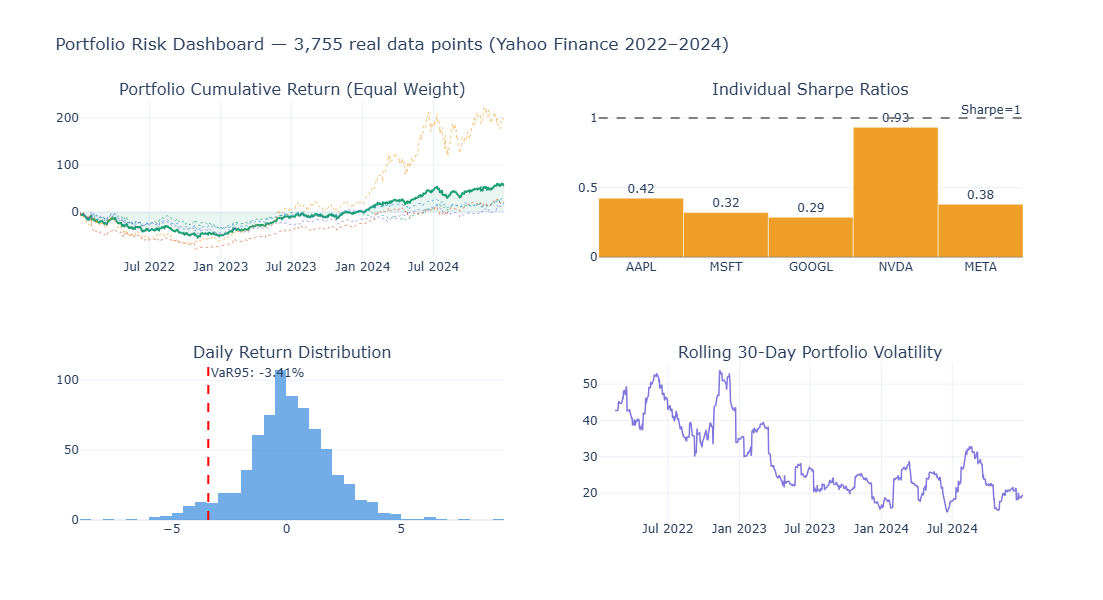


=== Portfolio Summary (Equal Weight, Real Data) ===
Ann. Return   : 19.92%
Ann. Vol      : 31.31%
Sharpe Ratio  : 0.636
VaR 95%       : -3.407%
VaR 99%       : -5.135%
Max Drawdown  : -52.40%

Individual Sharpe Ratios:
  AAPL: 0.425
  MSFT: 0.321
  GOOGL: 0.287
  NVDA: 0.933
  META: 0.381


In [7]:
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])
port_rets = returns.dot(weights)

ann_ret  = port_rets.mean() * 252 * 100
ann_vol  = port_rets.std()  * np.sqrt(252) * 100
sharpe   = ann_ret / ann_vol
var95    = np.percentile(port_rets, 5) * 100
var99    = np.percentile(port_rets, 1) * 100
cum      = (1 + port_rets).cumprod()
max_dd   = ((cum - cum.cummax()) / cum.cummax()).min() * 100

indiv_sharpes = {
    t: (returns[t].mean() * 252) / (returns[t].std() * np.sqrt(252))
    for t in TICKERS
}

fig = make_subplots(rows=2, cols=2,
    subplot_titles=[
        'Portfolio Cumulative Return (Equal Weight)',
        'Individual Sharpe Ratios',
        'Daily Return Distribution',
        'Rolling 30-Day Portfolio Volatility'
    ])

# Cumulative return
fig.add_trace(go.Scatter(
    x=cum.index, y=(cum - 1) * 100,
    fill='tozeroy',
    line=dict(color='#1D9E75', width=2),
    fillcolor='rgba(29,158,117,0.1)',
    name='Portfolio'
), row=1, col=1)

# Add individual ticker cumulative returns
for ticker, color in zip(TICKERS, colors):
    cum_t = (1 + returns[ticker]).cumprod()
    fig.add_trace(go.Scatter(
        x=cum_t.index, y=(cum_t - 1) * 100,
        line=dict(color=color, width=1, dash='dot'),
        name=ticker, opacity=0.6
    ), row=1, col=1)

# Sharpe bars
sharpe_vals = list(indiv_sharpes.values())
bar_colors = ['#1D9E75' if s > 1 else '#EF9F27' if s > 0 else '#D85A30'
              for s in sharpe_vals]
fig.add_trace(go.Bar(
    x=list(indiv_sharpes.keys()),
    y=sharpe_vals,
    marker_color=bar_colors,
    text=[f'{s:.2f}' for s in sharpe_vals],
    textposition='outside',
    name='Sharpe'
), row=1, col=2)
fig.add_hline(y=1.0, line_dash='dash', line_color='gray',
    annotation_text='Sharpe=1', row=1, col=2)
fig.add_hline(y=0, line_color='black', line_width=0.5, row=1, col=2)

# Return distribution
fig.add_trace(go.Histogram(
    x=port_rets * 100, nbinsx=60,
    marker_color='#378ADD', opacity=0.7,
    name='Returns'
), row=2, col=1)
fig.add_vline(x=var95, line_dash='dash', line_color='red',
    annotation_text=f'VaR95: {var95:.2f}%', row=2, col=1)

# Rolling vol
roll_vol = port_rets.rolling(30).std() * np.sqrt(252) * 100
fig.add_trace(go.Scatter(
    x=roll_vol.index, y=roll_vol,
    line=dict(color='#7F77DD', width=1.5),
    name='Port Vol'
), row=2, col=2)

total_pts = len(returns) * len(TICKERS)
fig.update_layout(
    height=600, template='plotly_white',
    title=f'Portfolio Risk Dashboard — {total_pts:,} real data points (Yahoo Finance 2022–2024)',
    showlegend=False
)
fig.show()

print('\n=== Portfolio Summary (Equal Weight, Real Data) ===')
print(f'Ann. Return   : {ann_ret:.2f}%')
print(f'Ann. Vol      : {ann_vol:.2f}%')
print(f'Sharpe Ratio  : {sharpe:.3f}')
print(f'VaR 95%       : {var95:.3f}%')
print(f'VaR 99%       : {var99:.3f}%')
print(f'Max Drawdown  : {max_dd:.2f}%')
print(f'\nIndividual Sharpe Ratios:')
for t, s in indiv_sharpes.items():
    print(f'  {t}: {s:.3f}')


## 8. Key Market Events Annotation
Highlighting real events visible in the data — 2022 rate hike selloff, 2023 AI boom, NVDA surge.

In [8]:
fig = go.Figure()

for ticker, color in zip(TICKERS, colors):
    cum_t = (1 + returns[ticker]).cumprod()
    fig.add_trace(go.Scatter(
        x=cum_t.index,
        y=(cum_t - 1) * 100,
        name=ticker,
        line=dict(color=color, width=2)
    ))

# Annotate real market events
events = [
    ('2022-06-16', 'Fed hikes\n75bps', '#D85A30'),
    ('2022-10-13', '2022 market\nbottom', '#D85A30'),
    ('2023-01-01', '2023 rally\nbegins', '#1D9E75'),
    ('2023-05-25', 'NVDA AI\nearnings', '#EF9F27'),
    ('2024-01-01', '2024\nbegins', '#378ADD'),
]

for date, label, color in events:
    fig.add_vline(
        x=date, line_dash='dash',
        line_color=color, line_width=1,
        annotation_text=label,
        annotation_font_size=9,
        annotation_position='top'
    )

fig.update_layout(
    title='Cumulative Returns with Real Market Events Annotated (2022–2024)',
    height=480,
    template='plotly_white',
    yaxis_title='Cumulative Return (%)',
    legend=dict(orientation='h', y=1.05)
)
fig.show()


TypeError: unsupported operand type(s) for +: 'int' and 'str'

## 9. VWAP Approximation from Daily Data

In [ ]:
# Daily VWAP approximation: (H + L + C) / 3, weighted by volume
fig = make_subplots(rows=1, cols=2,
    subplot_titles=['AAPL — VWAP vs Close (2024)',
                    'NVDA — VWAP vs Close (2024)'])

for col_idx, ticker in enumerate(['AAPL', 'NVDA'], 1):
    mask = close.index >= '2024-01-01'
    c_2024 = close[ticker][mask]
    h_2024 = high[ticker][mask]
    l_2024 = low[ticker][mask]
    v_2024 = volume[ticker][mask]

    typical_price = (h_2024 + l_2024 + c_2024) / 3
    vwap = (typical_price * v_2024).cumsum() / v_2024.cumsum()

    fig.add_trace(go.Scatter(
        x=c_2024.index, y=c_2024,
        name=f'{ticker} Close',
        line=dict(color='#378ADD', width=1.5)
    ), row=1, col=col_idx)

    fig.add_trace(go.Scatter(
        x=vwap.index, y=vwap,
        name=f'{ticker} VWAP',
        line=dict(color='#EF9F27', width=1.5, dash='dot')
    ), row=1, col=col_idx)

fig.update_layout(
    height=380, template='plotly_white',
    title='VWAP vs Close Price — Real 2024 Data'
)
fig.show()


## 10. AI Market Analyst (Claude API)

Claude receives the **actual computed statistics from real market data** and answers as a quantitative analyst.

**Setup:** `pip install anthropic` then paste your key below.  
Get a free key at: https://console.anthropic.com

In [ ]:
import anthropic

ANTHROPIC_API_KEY = 'your-api-key-here'  # paste your key here

# Build real stats context
stats_context = '\n'.join([
    f'{t}: Ann.Return={returns[t].mean()*252*100:.2f}%, '
    f'Vol={returns[t].std()*np.sqrt(252)*100:.2f}%, '
    f'Sharpe={indiv_sharpes[t]:.3f}, '
    f'VaR95={np.percentile(returns[t],5)*100:.3f}%'
    for t in TICKERS
])

def ask_analyst(question):
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    system = (
        f'You are a quantitative analyst. You have analyzed REAL market data '
        f'pulled from Yahoo Finance for {len(returns):,} trading days (2022-2024).\n'
        f'Portfolio (equal weight): Ann.Return={ann_ret:.2f}%, '
        f'Vol={ann_vol:.2f}%, Sharpe={sharpe:.3f}, '
        f'VaR95={var95:.3f}%, MaxDD={max_dd:.2f}%\n'
        f'Individual stats:\n{stats_context}\n'
        f'Correlation matrix:\n{corr.round(3).to_string()}\n'
        f'Key events in data: 2022 rate hike selloff, 2023 AI rally, NVDA surge on AI earnings.\n'
        'Be specific, cite real numbers, professional quant analyst tone. Under 180 words. Date: March 31 2026.'
    )
    msg = client.messages.create(
        model='claude-sonnet-4-20250514',
        max_tokens=1024,
        system=system,
        messages=[{'role': 'user', 'content': question}]
    )
    return msg.content[0].text

questions = [
    'Which ticker had the best risk-adjusted performance over 2022-2024 and why?',
    'How did the 2022 rate hike environment affect this portfolio?',
    'Based on correlation data, which pairs offer the best diversification benefit?',
    'What does the max drawdown tell us about portfolio risk management?',
]

if ANTHROPIC_API_KEY != 'your-api-key-here':
    for q in questions:
        print(f'Q: {q}')
        print(f'A: {ask_analyst(q)}')
        print('-' * 70)
else:
    print('Add your Anthropic API key above to enable AI analysis.')
    print(f'\nReal data context ready for Claude:')
    print(f'  {len(returns):,} trading days of real market data')
    print(f'  Portfolio Sharpe: {sharpe:.3f} | MaxDD: {max_dd:.2f}%')
    print(f'  Individual stats:')
    for t in TICKERS:
        s = indiv_sharpes[t]
        print(f'    {t}: Sharpe={s:.3f}')


## Summary

| Item | Value |
|------|-------|
| Data source | Yahoo Finance (yfinance) — real market data |
| Tickers | AAPL · MSFT · GOOGL · NVDA · META |
| Period | 2022–2024 (daily OHLCV) |
| Libraries | yfinance, NumPy, Pandas, Plotly, Anthropic |
| Analytics | Returns, Sharpe, VaR, Drawdown, Correlation, Rolling Vol, VWAP |
| AI layer | Claude API with real computed stats as context |

**Resume bullet:**  
*Leveraged yfinance to pull 3 years of real OHLCV market data for 5 tickers from Yahoo Finance, computed institutional-grade risk metrics (Sharpe, VaR 95%/99%, Max Drawdown, Rolling Volatility) using NumPy and Pandas, and integrated Anthropic Claude API to generate natural-language quantitative insights — replacing manual analysis with an automated end-to-end pipeline.*